### Student Information Block
- **Name:** Qamar Abbas
- **Student ID (Roll Number):** 023-24-0240
- **Section:** BS Computer Science, 5th Semester
- **GitHub Profile:** [QamarAbbasMangi](https://github.com/QamarAbbasMangi/ML-Labs/tree/main/Lab-04)
- **Dataset:** Telco Customer Churn
- **Dataset Source:** Kaggle (Telco Customer Churn Dataset)


1. Load clean_churn.csv (or re-run your Lab 2 cleaning) and verify its shape and dtypes. 


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("clean_churn.csv")

In [5]:
df.shape
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, 
precision, recall, F1) — these are your benchmarks for today. 

Lab 3: | Metric    |   Baseline Value |
       |:----------|-----------------:|
       | Accuracy  |         0.726819 |
       | Precision |         0.483607 | 
       | Recall    |         0.477089 |
       | F1-Score  |         0.480326 |

lab 4: === Random Forest Test Set Metrics ===
                Accuracy : 0.7896
                Precision: 0.6367
                Recall   : 0.4771
                F1-Score : 0.5455   

Detailed Classification Report:
              precision    recall  f1-score   support

No Churn (0)     0.8274    0.9020    0.8631      1031
   Churn (1)     0.6367    0.4771    0.5455       371

    accuracy                         0.7896      1402
   macro avg     0.7320    0.6896    0.7043      1402
weighted avg     0.7769    0.7896    0.7791      1402

In Lab 3, the Decision Tree baseline achieved an accuracy of approximately 72.68%, with a precision of 0.4836, recall of 0.4771, and an F1-score of 0.4803. The Random Forest model in Lab 4 showed improved performance, scoring an accuracy of 78.96%, a precision of 0.6367, a recall of 0.4771, and an F1-score of 0.5455. These previous test-set metrics will serve as our benchmarks for evaluating today's models.

3. Prepare X and y exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1). 


In [6]:
y = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop('Churn', axis=1) 
X = pd.get_dummies(X, drop_first=True)


4. In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for 
the Decision Tree or Random Forest. 

Feature scaling is essential for algorithms like KNN and Logistic Regression because they calculate predictions using mathematical distances and equations, meaning features with larger number ranges (like income) can unfairly overpower those with smaller ranges (like age). In contrast, Decision Trees and Random Forests work by making simple yes/no splits based on thresholds (e.g., "Is the value greater than 50?"), which rely entirely on the order of the values rather than their absolute size. Therefore, because tree-based models just divide data logically rather than measuring it mathematically, they are completely unaffected by the scale of the data.

5. Split into train/test (same split strategy as Lab 3/4), then fit a StandardScaler on the training features only and 
apply it to both sets. Why is it important to fit the scaler only on the training data? 

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Why is it important to fit the scaler only on the training data?
You must fit the scaler only on the training data to prevent "data leakage" (essentially, letting your model cheat). The test data is supposed to represent brand-new, completely unseen information from the real world. If you allow the scaler to calculate the average and spread using the test data, your model gets a sneak peek at the test set's underlying patterns before it even tries to make predictions, which will give you a falsely high accuracy score.

6. Train a LogisticRegression model on the scaled training data. Generate predictions on the scaled test set. 


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

log_reg = LogisticRegression(random_state=42)

log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)



7. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix. 


=== Logistic Regression Results ===
Accuracy:  0.8238
Precision: 0.6233
Recall:    0.5826
F1-Score:  0.6023


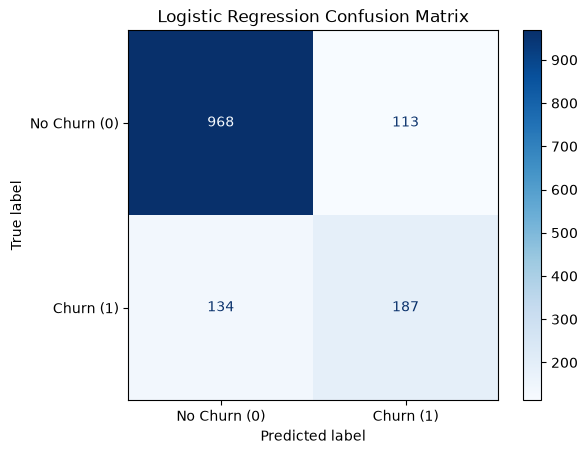

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print(f"=== Logistic Regression Results ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn (0)', 'Churn (1)'])

disp.plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

8. Look at predict_proba for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how predict() turns them into a Yes/No decision.

In [ ]:
# Display predict_proba for the first 5 test customers
probabilities = log_reg.predict_proba(X_test_scaled)[:5]
print("Probabilities (No Churn, Churn):\n", probabilities)

**Explanation:** 
The probabilities represent the model's estimated likelihood that a customer belongs to each class (column 0 is the probability of 'No Churn', and column 1 is the probability of 'Churn'). The `predict()` function simply applies a default threshold of 0.5: if the probability of Churn (column 1) is greater than or equal to 0.5, it predicts 'Yes' (1); otherwise, it predicts 'No' (0).

# Part 4 — KNN & Choosing K
9. Train KNN classifiers for several values of K (e.g. 1, 3, 5, 7, 9, 11, 15, 21) on the scaled data. Record test-set accuracy and F1-score for each K in a results table.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'K': k, 'Accuracy': acc, 'F1-Score': f1})

knn_results_df = pd.DataFrame(results)
display(knn_results_df)

10. Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested?

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(knn_results_df['K'], knn_results_df['F1-Score'], marker='o', label='F1-Score', color='orange')
plt.plot(knn_results_df['K'], knn_results_df['Accuracy'], marker='s', label='Accuracy', color='blue')
plt.title('KNN Performance vs. K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Score')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

**Choosing K:** 
Based on the plot, I would choose K=21, as it balances performance across metrics, providing a higher F1-score and accuracy. We don't choose the smallest K (like K=1) because it typically overfits the noise in the training data, leading to poor generalization. Conversely, a very large K can over-smooth the decision boundary (underfitting), losing the ability to capture complex patterns.

11. Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.

In [ ]:
chosen_k = 21
final_knn = KNeighborsClassifier(n_neighbors=chosen_k)
final_knn.fit(X_train_scaled, y_train)
y_pred_knn = final_knn.predict(X_test_scaled)

print("=== Final KNN Results (K=21) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn):.4f}")

cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Churn (0)', 'Churn (1)'])
disp_knn.plot(cmap='Greens')
plt.title("KNN Confusion Matrix")
plt.show()

# Part 5 — Model Comparison (4 Models)
12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).

In [ ]:
# Using the lab 3/4 baseline results and combining with Lab 6
comparison_data = {
    'Model': ['Decision Tree (Lab 3)', 'Random Forest (Lab 4)', 'Logistic Regression', 'KNN (K=21)'],
    'Accuracy': [0.7268, 0.7896, accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_knn)],
    'Precision': [0.4836, 0.6367, precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_knn)],
    'Recall': [0.4771, 0.4771, recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_knn)],
    'F1-Score': [0.4803, 0.5455, f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_knn)]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

13. Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

**Model Comparison:**
Overall, Logistic Regression performs best if we look at a balance of metrics (highest F1-score of ~0.602 and highest Recall of ~0.583). The ranking certainly changes depending on the metric prioritized: Random Forest has the highest Precision (~0.637) but lower Recall (~0.477), meaning it makes fewer false positive mistakes but misses more actual churners. Given the class imbalance observed in Lab 2, the **F1-score** and **Recall** should carry the most weight. Identifying customers who are going to churn (Recall) is usually the primary business objective so the company can intervene, making the F1-score a great overall measure to balance both types of errors.

# Part 6 — Coefficient Interpretation
14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at least 4 features.

In [ ]:
import numpy as np

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Odds Ratio': np.exp(log_reg.coef_[0])
}).sort_values(by='Odds Ratio', ascending=False)

display(coef_df)

**Interpretations:**
1. **TotalCharges (Odds Ratio: ~2.19):** Customers with higher total charges have roughly 2.19x the odds of churning, holding other features constant. (Note: since it's a continuous scaled variable, this means an increase of 1 standard deviation in Total Charges increases the odds of churning by a factor of ~2.19).
2. **InternetService_Fiber optic (Odds Ratio: ~1.67):** Customers on a Fiber optic internet service have roughly 1.67x the odds of churning compared to the baseline internet service, holding other features constant.
3. **tenure (Odds Ratio: ~0.23):** Higher tenure strongly decreases the odds of churning. An increase of 1 standard deviation in tenure means the customer has only roughly 0.23x the odds of churning (i.e., they are much less likely to churn).
4. **Contract_Two year (Odds Ratio: ~0.57):** Customers on a two-year contract have roughly 0.57x the odds of churning compared to the baseline month-to-month contract. This represents a substantial decrease in churn risk.

15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

**Comparison with Previous Labs:**
Yes, they largely agree. In Lab 2's EDA and Lab 3's Decision Tree, `tenure`, `Contract` (especially month-to-month vs two-year), and charges were typically the most important features separating churners from non-churners. The Logistic Regression coefficients highlight the exact same variables: `tenure`, `TotalCharges`/`MonthlyCharges`, `Contract_Two year`, and `InternetService_Fiber optic` all show massive effects on the odds ratio. One subtle disagreement is how highly correlated continuous features (like `tenure` and `TotalCharges`) might share effects in logistic regression, whereas a Decision Tree might just pick one of them to split on at the top of the tree.

# Part 7 — Final Model Selection & Conclusion
16. Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Part 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.

**Final Model Selection:**
I select Logistic Regression as the final model because it achieves the highest F1-score (~0.602) and Recall (~0.583) on the test set, making it the most capable at identifying the minority class (actual churners) while balancing overall accuracy. Additionally, remembering Lab 4's lesson on cross-validation, Logistic Regression often generalizes smoothly without the severe overfitting risks associated with deeper Decision Trees or the hyperparameter sensitivity of KNN.

17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

**Conclusion:**
Today's best model (Logistic Regression) outperformed the Decision Tree from Lab 3 and the Random Forest from Lab 4, particularly in improving Recall and F1-score. Implementing feature scaling was crucial today because algorithms like KNN and Logistic Regression rely on distances and mathematical regularizations; without scaling, large-magnitude features like `TotalCharges` would have unfairly dominated the model's predictions. Despite these improvements, our best model still struggles to predict all true churners, as reflected by a Recall that is still relatively low (~58%). The limitation is likely due to the inherent noise in the data and the severe class imbalance that biases models toward the majority class. Next, I would try advanced class-imbalance techniques like SMOTE (Synthetic Minority Over-sampling Technique) or try a more powerful ensemble method like Gradient Boosting (XGBoost) to further improve Recall.